In [1]:
import pandas as pd
df = pd.read_csv('/content/swiggy.csv', on_bad_lines='skip', engine='python')
df = df.drop(columns=['link'])
df.head()

,id,name,city,rating,rating_count,cost,cuisine,lic_no,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [2]:
df.describe()

,id
count,98375.000000
mean,361329.180788
std,168628.986737
min,211.000000
25%,235619.500000
50%,410130.000000
75%,500312.000000
max,581031.000000


In [3]:
original_rows_before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
rows_removed_duplicates = original_rows_before_duplicates - df.shape[0]

print(f"Number of rows removed due to duplicates: {rows_removed_duplicates}")
print(f"DataFrame shape after dropping duplicates: {df.shape}")

Number of rows removed due to duplicates: 0
DataFrame shape after dropping duplicates: (98375, 10)


In [4]:
print("Missing values per column before dropping:")
print(df.isnull().sum())

original_rows_before_na = df.shape[0]
df.dropna(inplace=True)
rows_removed_due_to_na = original_rows_before_na - df.shape[0]

print(f"\nNumber of rows removed due to missing values: {rows_removed_due_to_na}")
print(f"DataFrame shape after dropping missing values: {df.shape}")

Missing values per column before dropping:
id                0
name             37
city              0
rating           37
rating_count     37
cost             68
cuisine          43
lic_no          138
address          38
menu              1
dtype: int64

Number of rows removed due to missing values: 176
DataFrame shape after dropping missing values: (98199, 10)


In [5]:
df.to_csv('cleaned_data.csv', index=False)
print("Cleaned data saved to 'cleaned_data.csv'")

Cleaned data saved to 'cleaned_data.csv'


In [6]:
df=pd.read_csv('/content/cleaned_data.csv')
df.head()

print("\n--- Verifying Cleaned Data ---")
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
missing_values_count = df.isnull().sum().sum()
print(f"Number of missing values: {missing_values_count}")

if num_duplicates == 0 and missing_values_count == 0:
    print("The data appears to be clean (no duplicates or missing values).")
else:
    print("Warning: Duplicates or missing values found, review cleaning steps.")

print(f"Current DataFrame shape: {df.shape}")


--- Verifying Cleaned Data ---
Number of duplicate rows: 0
Number of missing values: 0
The data appears to be clean (no duplicates or missing values).
Current DataFrame shape: (98199, 10)


# **DATA PREPROCESSING**

In [7]:
print("Unique values in 'city':", df['city'].nunique())
print("Unique values in 'rating':", df['rating'].nunique())
print("Unique values in 'rating_count':", df['rating_count'].nunique())
print("Unique values in 'cost':", df['cost'].nunique())
print("Unique values in 'cuisine':", df['cuisine'].nunique())

print("\nValue counts for 'rating':")
print(df['rating'].value_counts())

print("\nValue counts for 'rating_count':")
print(df['rating_count'].value_counts().head(10))

print("\nValue counts for 'cost':")
print(df['cost'].value_counts().head(10))

Unique values in 'city': 507
Unique values in 'rating': 42
Unique values in 'rating_count': 8
Unique values in 'cost': 329
Unique values in 'cuisine': 1858

Value counts for 'rating':
rating
--     56908
4.0     4487
4.1     4339
4.2     4081
3.8     3717
3.9     3635
4.3     3482
3.7     2778
4.4     2166
3.5     1919
3.6     1894
4.5     1249
3.4     1196
3.3     1145
4.6      936
3.2      734
3.0      554
3.1      507
4.7      438
2.9      307
2.8      290
4.8      241
2.7      198
2.5      156
5.0      149
2.6      135
4.9      127
2.3       90
2.4       74
2.2       64
2.0       53
2.1       46
1.9       34
1.8       22
1.5       12
1.6       11
1.4       10
1.7        8
1.2        3
1.3        2
1.1        1
1.0        1
Name: count, dtype: int64

Value counts for 'rating_count':
rating_count
Too Few Ratings    56908
20+ ratings        14201
100+ ratings       13826
50+ ratings         7986
500+ ratings        3112
1K+ ratings         2069
5K+ ratings           83
10K+ ratings   

In [8]:
df['rating'] = df['rating'].replace('--', None)
df['rating'] = pd.to_numeric(df['rating'])

print("Data type of 'rating' after conversion:", df['rating'].dtype)
print("Value counts for 'rating' after conversion (top 10):\n", df['rating'].value_counts(dropna=False).head(10))

Data type of 'rating' after conversion: float64
Value counts for 'rating' after conversion (top 10):
 rating
NaN    56908
4.0     4487
4.1     4339
4.2     4081
3.8     3717
3.9     3635
4.3     3482
3.7     2778
4.4     2166
3.5     1919
Name: count, dtype: int64


In [9]:
def parse_rating_count(count_str):
    if count_str == 'Too Few Ratings':
        return 0
    elif '+' in count_str:
        count_str = count_str.replace(' ratings', '').replace('+', '')
        if 'K' in count_str:
            return float(count_str.replace('K', '')) * 1000
        else:
            return float(count_str)
    return float(count_str)

df['rating_count'] = df['rating_count'].apply(parse_rating_count)

print("Data type of 'rating_count' after conversion:", df['rating_count'].dtype)
print("Value counts for 'rating_count' after conversion (top 10):\n", df['rating_count'].value_counts().head(10))

Data type of 'rating_count' after conversion: float64
Value counts for 'rating_count' after conversion (top 10):
 rating_count
0.0        56908
20.0       14201
100.0      13826
50.0        7986
500.0       3112
1000.0      2069
5000.0        83
10000.0       14
Name: count, dtype: int64


In [10]:
df['cost'] = df['cost'].str.replace('₹ ', '').astype(float)

print("Data type of 'cost' after conversion:", df['cost'].dtype)
print("Value counts for 'cost' after conversion (top 10):\n", df['cost'].value_counts().head(10))

Data type of 'cost' after conversion: float64
Value counts for 'cost' after conversion (top 10):
 cost
200.0    25247
300.0    19858
250.0    13130
150.0     7830
400.0     7652
500.0     4253
350.0     4234
100.0     3918
600.0     1769
450.0     1019
Name: count, dtype: int64


In [11]:
print("DataFrame Info after type conversions:")
df.info()

DataFrame Info after type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98199 entries, 0 to 98198
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            98199 non-null  int64  
 1   name          98199 non-null  object 
 2   city          98199 non-null  object 
 3   rating        41291 non-null  float64
 4   rating_count  98199 non-null  float64
 5   cost          98199 non-null  float64
 6   cuisine       98199 non-null  object 
 7   lic_no        98199 non-null  object 
 8   address       98199 non-null  object 
 9   menu          98199 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 7.5+ MB


In [12]:
if 'cuisine' in df.columns:
    unique_cuisines = df['cuisine'].dropna().str.split(',').explode().str.strip().unique()

    print(f"Number of unique cuisines: {len(unique_cuisines)}")
    print(f"First 10 unique cuisines: {unique_cuisines[:10]}")

else:
    print("Error: The 'cuisine' column is not found in the DataFrame.")
    if 'unique_cuisines' in globals() and unique_cuisines is not None:
        print(f"Using previously extracted data (Count: {len(unique_cuisines)}):")
        print(f"First 10: {unique_cuisines[:10]}")
    else:
        print("No fallback 'unique_cuisines' data is available.")

Number of unique cuisines: 116
First 10 unique cuisines: ['Beverages' 'Pizzas' 'Sweets' 'Bakery' 'Fast Food' 'Indian'
 'Italian-American' 'Continental' 'North Indian' 'Snacks']


In [13]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
cuisine_encoded = pd.DataFrame(mlb.fit_transform(df['cuisine'].str.split(',').apply(lambda x: [item.strip() for item in x])), columns=mlb.classes_, index=df.index)

df = df.join(cuisine_encoded)

print("Shape of DataFrame after cuisine encoding:", df.shape)
print("First 5 rows of encoded cuisines:")
print(df[mlb.classes_].head())

Shape of DataFrame after cuisine encoding: (98199, 126)
First 5 rows of encoded cuisines:
   8:15 To 11:30 Pm  Afghani  African  American  Andhra  Arabian  Asian  \
0                 0        0        0         0       0        0      0   
1                 0        0        0         0       0        0      0   
2                 0        0        0         0       0        0      0   
3                 0        0        0         0       0        0      0   
4                 0        0        0         0       0        0      0   

   Assamese  Attractive Combos Available  Australian  ...  Telangana  Tex-Mex  \
0         0                            0           0  ...          0        0   
1         0                            0           0  ...          0        0   
2         0                            0           0  ...          0        0   
3         0                            0           0  ...          0        0   
4         0                            0           0  

In [14]:
df = pd.get_dummies(df, columns=['city'], prefix='city')

print("Shape of DataFrame after city encoding:", df.shape)
print("First 5 rows of city encoded columns:")
print(df.filter(like='city_').head())

Shape of DataFrame after city encoding: (98199, 632)
First 5 rows of city encoded columns:
   city_Abids & Koti,Hyderabad  city_Abohar  city_Adilabad  city_Adityapur  \
0                        False         True          False           False   
1                        False         True          False           False   
2                        False         True          False           False   
3                        False         True          False           False   
4                        False         True          False           False   

   city_Adoni  city_Adyar,Chennai  city_Agartala  city_Agra  city_Ahmednagar  \
0       False               False          False      False            False   
1       False               False          False      False            False   
2       False               False          False      False            False   
3       False               False          False      False            False   
4       False               False       

In [15]:
import pickle

# Save the mlb object to a file
with open('encoder.pkl', 'wb') as f:
    pickle.dump(mlb, f)

print("MultiLabelBinarizer saved to 'encoder.pkl'")

MultiLabelBinarizer saved to 'encoder.pkl'


In [16]:
print("DataFrame Info after all encoding steps:")
df.info()

DataFrame Info after all encoding steps:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98199 entries, 0 to 98198
Columns: 632 entries, id to city_sohna road,Gurgaon
dtypes: bool(507), float64(3), int64(117), object(5)
memory usage: 141.1+ MB


In [17]:
object_columns = df.select_dtypes(include='object').columns
print(f"Non-numerical columns identified: {list(object_columns)}")

df_features = df.drop(columns=object_columns)

print("DataFrame Info after dropping non-numerical columns:")
df_features.info()

Non-numerical columns identified: ['name', 'cuisine', 'lic_no', 'address', 'menu']
DataFrame Info after dropping non-numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98199 entries, 0 to 98198
Columns: 627 entries, id to city_sohna road,Gurgaon
dtypes: bool(507), float64(3), int64(117)
memory usage: 137.4 MB


In [18]:
import pickle
import pandas as pd
with open('/content/encoder.pkl', 'rb') as file:
    loaded_mlb = pickle.load(file)
example_new_cuisine_data = [
    ['North Indian', 'Fast Food'],
    ['Italian', 'Pizzas', 'Beverages'],
    ['South Indian'],
    ['Fast Food', 'Snacks', 'Chinese']
]
encoded_new_data = loaded_mlb.transform(example_new_cuisine_data)
encoded_df = pd.DataFrame(encoded_new_data, columns=loaded_mlb.classes_)

print("Encoded new cuisine data (first 5 rows if more exist):")
print(encoded_df.head())

Encoded new cuisine data (first 5 rows if more exist):
   8:15 To 11:30 Pm  Afghani  African  American  Andhra  Arabian  Asian  \
0                 0        0        0         0       0        0      0   
1                 0        0        0         0       0        0      0   
2                 0        0        0         0       0        0      0   
3                 0        0        0         0       0        0      0   

   Assamese  Attractive Combos Available  Australian  ...  Telangana  Tex-Mex  \
0         0                            0           0  ...          0        0   
1         0                            0           0  ...          0        0   
2         0                            0           0  ...          0        0   
3         0                            0           0  ...          0        0   

   Thai  Thalis  Tibetan  Tribal  Turkish  Use Code JUMBO30 to avail  \
0     0       0        0       0        0                          0   
1     0       0    

In [19]:
# Assign the processed features DataFrame to df_encoded
df_encoded = df_features.copy()

# df_encoded_features should exclude 'id' for clustering but keep everything else
df_encoded_features = df_encoded.drop(columns=['id'])

print("Encoded Data (df_encoded):")
print(df_encoded.head())

print("\nEncoded Features for clustering (df_encoded_features):")
print(df_encoded_features.head())

df_cleaned = pd.read_csv('cleaned_data.csv')
print("\nCleaned Data (df_cleaned):")
print(df_cleaned.head())

Encoded Data (df_encoded):
       id  rating  rating_count   cost  8:15 To 11:30 Pm  Afghani  African  \
0  567335     NaN           0.0  200.0                 0        0        0   
1  531342     4.4          50.0  200.0                 0        0        0   
2  158203     3.8         100.0  100.0                 0        0        0   
3  187912     3.7          20.0  250.0                 0        0        0   
4  543530     NaN           0.0  250.0                 0        0        0   

   American  Andhra  Arabian  ...  city_Vijay Nagar,Indore  \
0         0       0        0  ...                    False   
1         0       0        0  ...                    False   
2         0       0        0  ...                    False   
3         0       0        0  ...                    False   
4         0       0        0  ...                    False   

   city_Villivakkam,Chennai  city_Vyttila,Kochi  city_West Chd,Chandigarh  \
0                     False               False       

In [20]:
# Fill missing 'rating' values in df_encoded if any, before clustering
df_encoded['rating'] = df_encoded['rating'].fillna(0)

print("Missing values in 'rating' after filling:")
print(df_encoded['rating'].isnull().sum())

Missing values in 'rating' after filling:
0


In [21]:
df_encoded_features['rating'] = df_encoded_features['rating'].fillna(0)

print("Shape of df_encoded_features:", df_encoded_features.shape)
print("First 5 rows of df_encoded_features:")
print(df_encoded_features.head())

Shape of df_encoded_features: (98199, 626)
First 5 rows of df_encoded_features:
   rating  rating_count   cost  8:15 To 11:30 Pm  Afghani  African  American  \
0     0.0           0.0  200.0                 0        0        0         0   
1     4.4          50.0  200.0                 0        0        0         0   
2     3.8         100.0  100.0                 0        0        0         0   
3     3.7          20.0  250.0                 0        0        0         0   
4     0.0           0.0  250.0                 0        0        0         0   

   Andhra  Arabian  Asian  ...  city_Vijay Nagar,Indore  \
0       0        0      0  ...                    False   
1       0        0      0  ...                    False   
2       0        0      0  ...                    False   
3       0        0      0  ...                    False   
4       0        0      0  ...                    False   

   city_Villivakkam,Chennai  city_Vyttila,Kochi  city_West Chd,Chandigarh  \
0      

In [22]:
inertia = []
print("Initialized an empty list 'inertia'.")

Initialized an empty list 'inertia'.


In [23]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer
df = pd.read_csv('/content/cleaned_data.csv')
df['rating'] = df['rating'].replace('--', None)
df['rating'] = pd.to_numeric(df['rating'])
def parse_rating_count(count_str):
    if count_str == 'Too Few Ratings':
        return 0
    elif '+' in count_str:
        count_str = count_str.replace(' ratings', '').replace('+', '')
        if 'K' in count_str:
            return float(count_str.replace('K', '')) * 1000
        else:
            return float(count_str)
    return float(count_str)
df['rating_count'] = df['rating_count'].apply(parse_rating_count)
df['cost'] = df['cost'].str.replace('₹ ', '').astype(float)
mlb = MultiLabelBinarizer()
cuisine_encoded = pd.DataFrame(mlb.fit_transform(df['cuisine'].str.split(',').apply(lambda x: [item.strip() for item in x])), columns=mlb.classes_, index=df.index)
df = df.join(cuisine_encoded)
df = pd.get_dummies(df, columns=['city'], prefix='city')
object_columns = df.select_dtypes(include='object').columns
df_features = df.drop(columns=object_columns)
df_encoded = df_features.copy()
df_encoded_features = df_encoded.drop(columns=['id'], errors='ignore')
df_encoded['rating'] = df_encoded['rating'].fillna(0)
df_encoded_features['rating'] = df_encoded_features['rating'].fillna(0)
if 'inertia' not in globals() or len(inertia) > 0:
    inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_encoded_features)
    inertia.append(kmeans.inertia_)

print("Inertia values calculated for k from 1 to 10.")
for k_val, inv in enumerate(inertia, 1):
    print(f"k={k_val}: Inertia = {inv:.2f}")

Inertia values calculated for k from 1 to 10.
k=1: Inertia = 98924836342.28
k=2: Inertia = 8888014773.03
k=3: Inertia = 5779511403.20
k=4: Inertia = 3523429799.86
k=5: Inertia = 2216096901.32
k=6: Inertia = 1907780688.63
k=7: Inertia = 1270022235.95
k=8: Inertia = 1011652253.52
k=9: Inertia = 724211980.43
k=10: Inertia = 567773009.33


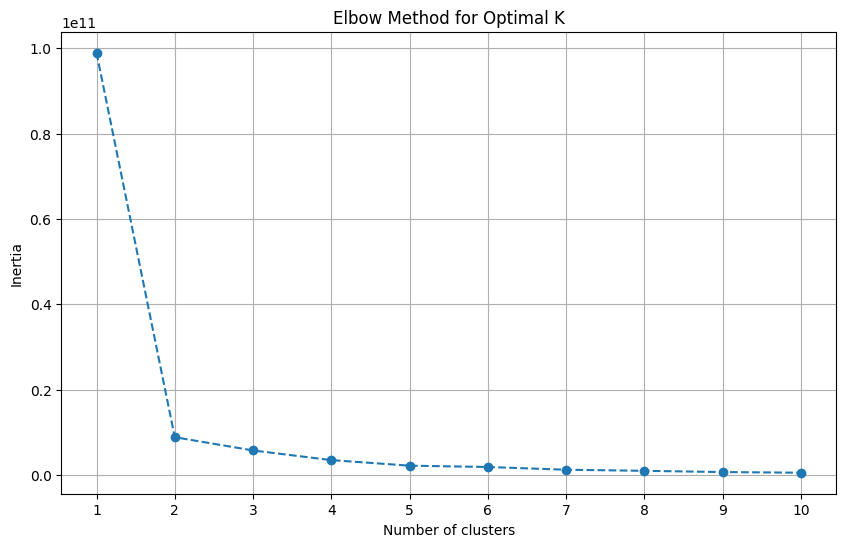

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


In [25]:
from sklearn.cluster import KMeans

# Ensure df_encoded and df_encoded_features are defined
# (These lines are added for robustness against potential kernel state loss)
df_encoded = df_features.copy()
df_encoded_features = df_encoded.drop(columns=['id'], errors='ignore')
# Re-apply any necessary fillna for 'rating' if it was part of df_encoded_features preparation
df_encoded['rating'] = df_encoded['rating'].fillna(0)
df_encoded_features['rating'] = df_encoded_features['rating'].fillna(0)

optimal_k = 4 # Based on the visual inspection of the elbow plot

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Fit the model and assign cluster labels to the original df_encoded DataFrame
df_encoded['cluster_label'] = kmeans_final.fit_predict(df_encoded_features)

# Save the df_encoded DataFrame to CSV AFTER the cluster_label has been added
df_encoded.to_csv('encoded_data.csv', index=False)

print(f"Assigned cluster labels for optimal_k = {optimal_k}")
print("First 5 rows with cluster labels:")
print(df_encoded[['id', 'cluster_label']].head())
print("\nUpdated 'encoded_data.csv' with cluster labels for Streamlit app.")

Assigned cluster labels for optimal_k = 4
First 5 rows with cluster labels:
       id  cluster_label
0  567335              0
1  531342              0
2  158203              0
3  187912              0
4  543530              0

Updated 'encoded_data.csv' with cluster labels for Streamlit app.


In [26]:
import pandas as pd
df_cleaned = pd.read_csv('cleaned_data.csv')

df_cleaned = pd.merge(df_cleaned, df_encoded[['id', 'cluster_label']], on='id', how='left')

print("First 5 rows of df_cleaned with cluster labels:")
print(df_cleaned.head())

First 5 rows of df_cleaned with cluster labels:
       id               name    city rating     rating_count   cost  \
0  567335     AB FOODS POINT  Abohar     --  Too Few Ratings  ₹ 200   
1  531342  Janta Sweet House  Abohar    4.4      50+ ratings  ₹ 200   
2  158203  theka coffee desi  Abohar    3.8     100+ ratings  ₹ 100   
3  187912          Singh Hut  Abohar    3.7      20+ ratings  ₹ 250   
4  543530      GRILL MASTERS  Abohar     --  Too Few Ratings  ₹ 250   

                      cuisine          lic_no  \
0            Beverages,Pizzas  22122652000138   
1               Sweets,Bakery  12117201000112   
2                   Beverages  22121652000190   
3            Fast Food,Indian  22119652000167   
4  Italian-American,Fast Food  12122201000053   

                                             address              menu  \
0  AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...  Menu/567335.json   
1  Janta Sweet House, Bazar No.9, Circullar Road,...  Menu/531342.json   
2       

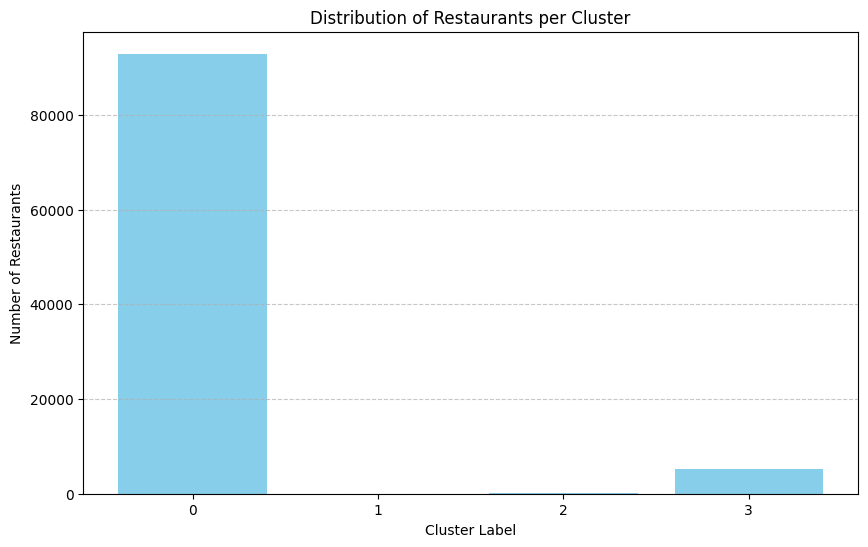

Cluster distribution:
cluster_label
0    92920
1        1
2       97
3     5181
Name: count, dtype: int64


In [27]:
import matplotlib.pyplot as plt

cluster_counts = df_cleaned['cluster_label'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(cluster_counts.index, cluster_counts.values, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of Restaurants per Cluster')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Cluster distribution:")
print(cluster_counts)

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_restaurants(restaurant_name, num_recommendations=10):
    try:
        global df_cleaned
        global df_encoded_features
        idx = df_cleaned[df_cleaned['name'] == restaurant_name].index[0]
    except IndexError:
        print(f"Restaurant '{restaurant_name}' not found.")
        return pd.DataFrame()

    input_vector = df_encoded_features.iloc[idx].values.reshape(1, -1)
    sim_scores = cosine_similarity(input_vector, df_encoded_features).flatten()
    sim_scores_series = pd.Series(sim_scores, index=df_cleaned.index)
    sim_scores_series = sim_scores_series.drop(idx)

    top_indices = sim_scores_series.nlargest(num_recommendations).index
    recommendations = df_cleaned.loc[top_indices]
    recommendations['similarity'] = sim_scores_series.loc[top_indices]

    return recommendations[['name', 'city', 'cuisine', 'rating', 'cost', 'similarity']]


if 'df_cleaned' in globals() and not df_cleaned.empty:
    example_restaurant = df_cleaned['name'].sample(1).iloc[0]
    print(f"Recommendations for '{example_restaurant}':")
    recommendations = recommend_restaurants(example_restaurant, num_recommendations=5)
    print(recommendations)
else:
    print("df_cleaned or df_encoded_features not found. Please ensure data loading and preprocessing cells are executed.")

Recommendations for 'Cafe 7':
                     name                   city              cuisine rating  \
23802       Hotel Jagdamb               Baramati            Fast Food     --   
92329          The Hub Co      Ruby Area,Kolkata  Fast Food,Beverages     --   
97903   Candid Resto Cafe              Kozhikode  Beverages,Fast Food     --   
50266      BURGER SHURGER     Punjabi Bagh,Delhi  Fast Food,Beverages     --   
9720   Mise En Place Cafe  Koramangala,Bangalore  Fast Food,Beverages     --   

        cost  similarity  
23802  ₹ 250    0.999994  
92329  ₹ 450    0.999991  
97903  ₹ 450    0.999991  
50266  ₹ 498    0.999991  
9720   ₹ 500    0.999991  


In [29]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.5 MB/s eta 0:00:00


In [30]:
!pip install streamlit pandas scikit-learn plotly

In [31]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import os

# --- 1. Page Configuration ---
st.set_page_config(page_title="Restaurant Recommender", layout="wide", page_icon="🍴")

# --- 2. Data Loading & Cleaning ---
@st.cache_data
def load_data():
    try:
        if not os.path.exists('cleaned_data.csv') or not os.path.exists('encoded_data.csv'):
            st.error("Data files missing! Ensure they are in the same directory.")
            return pd.DataFrame(), pd.DataFrame()

        df_cleaned = pd.read_csv('cleaned_data.csv', encoding='utf-8-sig')
        df_encoded_full = pd.read_csv('encoded_data.csv', encoding='utf-8-sig')

        df_cleaned['id'] = df_cleaned['id'].astype(str)
        df_encoded_full['id'] = df_encoded_full['id'].astype(str)

        common_ids = pd.merge(df_cleaned[['id']], df_encoded_full[['id']], on='id', how='inner')['id']

        df_cleaned = df_cleaned[df_cleaned['id'].isin(common_ids)].set_index('id').sort_index()
        df_encoded_full = df_encoded_full[df_encoded_full['id'].isin(common_ids)].set_index('id').sort_index()

        df_cleaned.columns = [c.strip().lower().replace(" ", "_") for c in df_cleaned.columns]

        if 'cost' in df_cleaned.columns:
            df_cleaned['price'] = pd.to_numeric(df_cleaned['cost'].astype(str).str.replace(r'[₹,]', '', regex=True), errors='coerce').fillna(0)

        if 'rating' in df_cleaned.columns:
            df_cleaned['rating_numeric'] = pd.to_numeric(df_cleaned['rating'], errors='coerce').fillna(0.0)

        df_cleaned['cuisine'] = df_cleaned['cuisine'].fillna('Not Specified')

        cols_to_drop = ['cluster_label', 'name', 'city', 'cuisine', 'rating', 'cost']
        df_encoded_features = df_encoded_full.drop(columns=[c for c in cols_to_drop if c in df_encoded_full.columns], errors='ignore').fillna(0)

        return df_cleaned, df_encoded_features
    except Exception as e:
        st.error(f"Critical Error: {e}")
        return pd.DataFrame(), pd.DataFrame()

df_cleaned, df_encoded_features = load_data()

# --- 3. Recommendation Logic ---
def recommend_restaurants(restaurant_name, num_recommendations, df_display, df_features):
    try:
        row = df_display[df_display['name'] == restaurant_name]
        if row.empty: return pd.DataFrame()

        target_id = row.index[0]
        input_vector = df_features.loc[[target_id]].values
        sim_scores = cosine_similarity(input_vector, df_features).flatten()
        sim_series = pd.Series(sim_scores, index=df_features.index).drop(target_id, errors='ignore')

        top_ids = sim_series.nlargest(num_recommendations).index
        recs = df_display.loc[top_ids].copy()
        recs['similarity'] = sim_series.loc[top_ids]
        return recs.reset_index()
    except Exception as e:
        st.error(f"Logic Error: {e}")
        return pd.DataFrame()

# --- 4. Sidebar & UI ---
if not df_cleaned.empty:
    st.sidebar.header("🔍 Filters")
    selected_city = st.sidebar.selectbox("City", ["All"] + sorted(df_cleaned['city'].dropna().unique().tolist()))

    # Dynamic Cuisine List
    all_cuisines = set()
    df_cleaned['cuisine'].str.split(',').apply(lambda x: [all_cuisines.add(i.strip()) for i in x] if isinstance(x, list) else None)
    selected_cuisine = st.sidebar.selectbox("Cuisine", ["All"] + sorted(list(all_cuisines)))

    max_p = st.sidebar.slider("Max Budget (₹)", 0, 5000, 1000)
    min_r = st.sidebar.slider("Min Rating", 0.0, 5.0, 3.5)

    filtered_df = df_cleaned.copy()
    if selected_city != "All":
        filtered_df = filtered_df[filtered_df['city'] == selected_city]
    if selected_cuisine != "All":
        filtered_df = filtered_df[filtered_df['cuisine'].str.contains(selected_cuisine, case=False, na=False)]

    filtered_df = filtered_df[(filtered_df['price'] <= max_p) & (filtered_df['rating_numeric'] >= min_r)]

    st.title("🍽️ Restaurant Recommendation Engine")

    m1, m2, m3 = st.columns(3)
    m1.metric("Results", len(filtered_df))
    m2.metric("Avg Rating", f"{filtered_df['rating_numeric'].mean():.1f} ⭐")
    m3.metric("Avg Cost", f"₹{filtered_df['price'].mean():.0f}")

    tab1, tab2, tab3 = st.tabs(["✨ Recommendations", "📋 Filtered List", "📈 Analysis"])

    with tab1:
        st.subheader("Personalized Picks")
        target_rest = st.selectbox("Pick a restaurant:", df_cleaned['name'].unique())
        num_recs = st.slider("Count:", 1, 20, 5)

        if st.button("Find Similar 🚀"):
            recs = recommend_restaurants(target_rest, num_recs, df_cleaned, df_encoded_features)
            if not recs.empty:
                # Updated width='stretch' per 2026 requirements
                st.dataframe(recs[['name', 'city', 'cuisine', 'rating', 'price', 'similarity']], width='stretch', hide_index=True)
                fig = px.bar(recs, x='similarity', y='name', orientation='h', color_discrete_sequence=['orange'])
                st.plotly_chart(fig, width='stretch')

    with tab2:
        st.dataframe(filtered_df[['name', 'city', 'rating', 'price', 'cuisine']], width='stretch')

    with tab3:
        c1, c2 = st.columns(2)
        with c1:
            fig1 = px.histogram(df_cleaned, x='city', title="By City")
            st.plotly_chart(fig1, width='stretch')
        with c2:
            fig2 = px.scatter(filtered_df, x='price', y='rating_numeric', hover_name='name')
            st.plotly_chart(fig2, width='stretch')

Writing app.py


In [34]:
!wget -q -O - ipv4.icanhazip.com

34.11.181.193


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.11.181.193:8501

your url is: https://stale-needles-love.loca.lt
